## Master in Artificial Intelligence, UdC, USC, UVigo. 2025/2026
## COMPUTER VISION I

### Topic 4: Image Segmentation
### Part 1: intensity-based thresholding and clustering (0.80 pts.)
Remember: digital images are just two-dimensional data.
To segment a certain type of images,
we always need some prior knowledge of the information
that is available in the data. Here, we assume that the useful information
is given by more or less similar gray values and that the foreground
consist of typical objects as seen in out daily live.

Make sure the path to the image file meets your needs on your system.

In [1]:
images_path = './images/'

We import everything at the beginning, as the libs are needed later...

In [2]:
# !pip install seaborn opencv-python scikit-learn scipy matplotlib numpy

In [3]:
import cv2
import sys
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import mixture
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.stats import norm
from sklearn.cluster import DBSCAN

We instruct matplotlib to show gridlines in the visualization of
two-dimensional data (maybe this is already the default in your
environment).
Decide by yourself whether you like them to be displayed.

In [4]:
plt.rcParams.update({"axes.grid" : True})

#### Histogram thresholding

**Exercise 1:**
Read and visualize 'plates.png', and:
1. Calculate its histogram, and visualize it using matplotlib and pyplot
(1_intro_CV notebook).
1. Do the same using the “seaborn” package.
1. Compute a smoothed version of the histogram by using a kernel density
estimation (KDE) from the “seaborn” package.

**Key Concepts**

***Histogram***:
Graphical representation of the distribution of pixel intensities in an image.

Since the appearance of a histogram depends on the number of bins chosen,
it can sometimes look too irregular.
**KDE (Kernel Density Estimation)** offers a smoother,
continuous representation of the data distribution by placing a kernel
(usually a Gaussian function) on each data point and summing them,
hence, producing a continuous estimate of the probability density
instead of the blocky/stairy appearance of a histogram.

*More information about KDE: https://mathisonian.github.io/kde/*


We read the image (here the image of two plates)
and check whether the file could be handled.

In [5]:
img = cv2.imread(images_path + 'plates.png', cv2.IMREAD_GRAYSCALE)
if img is None:
  sys.exit('Input image not found, check the path')

Show image resolution.

In [6]:
img.shape

(357, 407)

You might want to display the image with cv2,
and close the image when done
(depending on your environment this OpenCV visualization might not work
nicely in the jupyter notebook).

In [7]:
cv2.imshow('image', img)
k = cv2.waitKey(0)

or display it here with pyplot

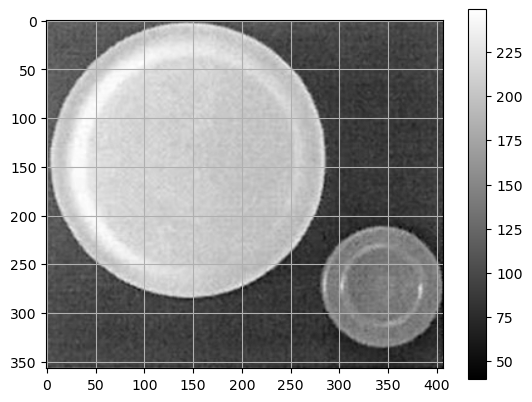

In [8]:
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

1. Calculate the histogram and visualize it using matplotlib and pyplot.

```
usage: matplotlib.pyplot.hist(
         x, bins=None, range=None, density=False, weights=None,
         cumulative=False, bottom=None, histtype='bar', align='mid',
         orientation='vertical', rwidth=None, log=False, color=None,
         label=None, stacked=False, *, data=None, **kwargs
      )
```

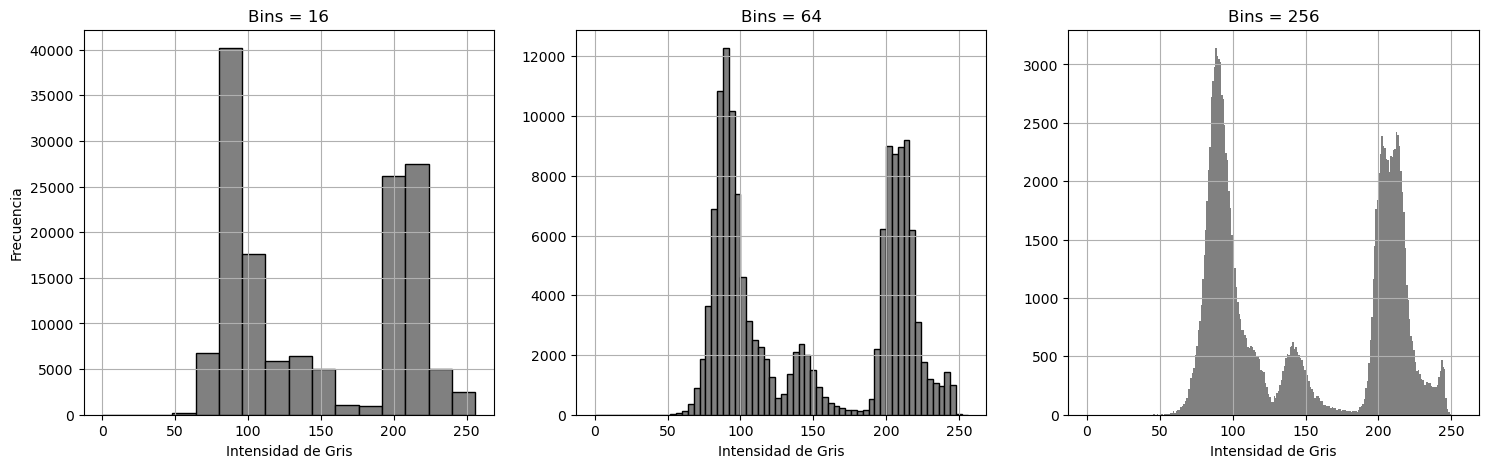

In [ ]:
# Visualize the histogram with matplotlib 
# - Try at least 2 more different values for 'bins' (for example, 16, 64, 256)
# - Comment on how the appearance of the histogram changes when varying 'bins.

#YOUR CODE HERE

# 1. Calculate the histogram and visualize it using matplotlib.pyplot.hist

# Flatten the image to 1D (x) because hist expects a one-dimensional array
pixels = img.reshape(-1)

plt.figure(figsize=(18, 5))

# Case 1: bins = 16
plt.subplot(1, 3, 1)
plt.hist(x=pixels, bins=16, range=[0, 256], color='gray', edgecolor='black')
plt.title("Bins = 16")
plt.xlabel("Gray Intensity"); plt.ylabel("Frequency")

# Case 2: bins = 64
plt.subplot(1, 3, 2)
plt.hist(x=pixels, bins=64, range=[0, 256], color='gray', edgecolor='black')
plt.title("Bins = 64")
plt.xlabel("Gray Intensity")

# Case 3: bins = 256 (Maximum detail for 8 bits)
plt.subplot(1, 3, 3)
plt.hist(x=pixels, bins=256, range=[0, 256], color='gray')
plt.title("Bins = 256")
plt.xlabel("Gray Intensity")

plt.show()


#plot.hist(img.resahpe(-1), bins=256, range=[0,256])
#plt.show()

2. Do the same using the “seaborn” package.

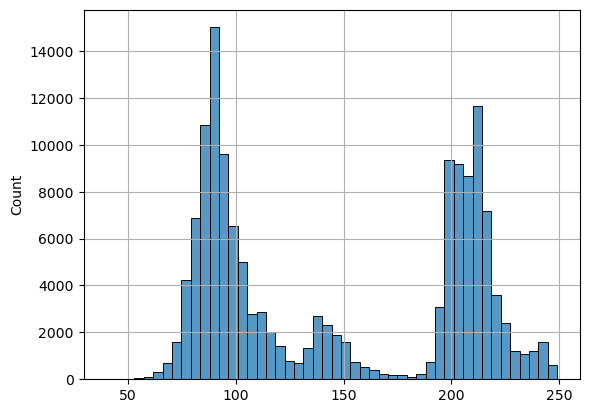

In [10]:
sns.histplot(img.reshape(-1))
plt.show()

3. Compute a smoothed version of the histogram using KDE from the
“seaborn” package.

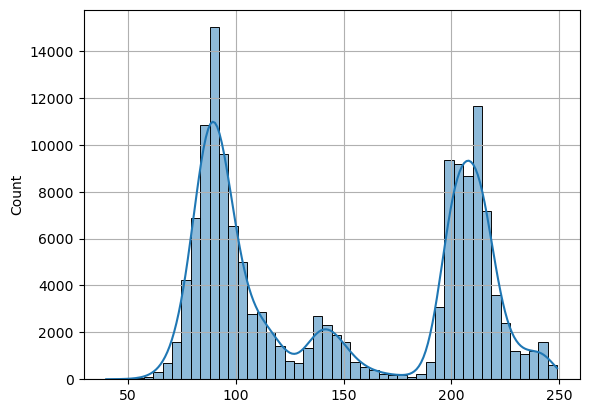

In [11]:
sns.histplot(img.reshape(-1), kde=True)
plt.show()

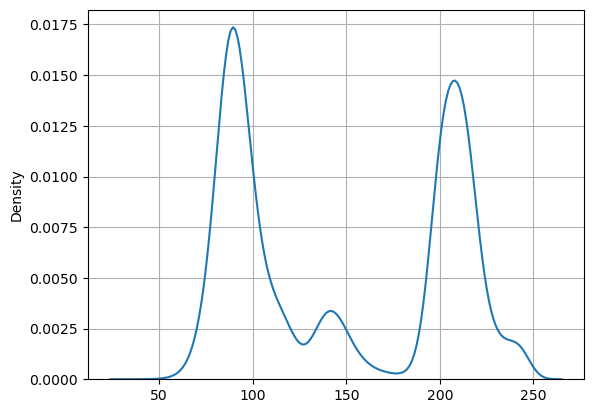

In [12]:
sns.kdeplot(img.reshape(-1))       # only kde
plt.show()

**Exercise 2 (0.05 pts):**
Apply multilevel thresholding to 'plates.png'.


1. What is the optimal number of levels?

The optimal number is 3 levels (or classes). 

Class 1 (Background): The darkest part of the image.

Class 2 (Shadow/Edge): The intermediate gray tones around the plates or in the shadows.

Class 3 (Plate): The brightest (white) part of the plates.This implies finding 2 thresholds ($T_1$ and $T_2$) that separate these three peaks.


2. How does the histogram change?

The original histogram is a "continuous" curve with peaks and valleys. The histogram of the segmented image becomes discrete: it will only have bars (non-zero frequency) at the 3 values you have chosen ($V_1, V_2, V_3$). The rest of the histogram will be empty.

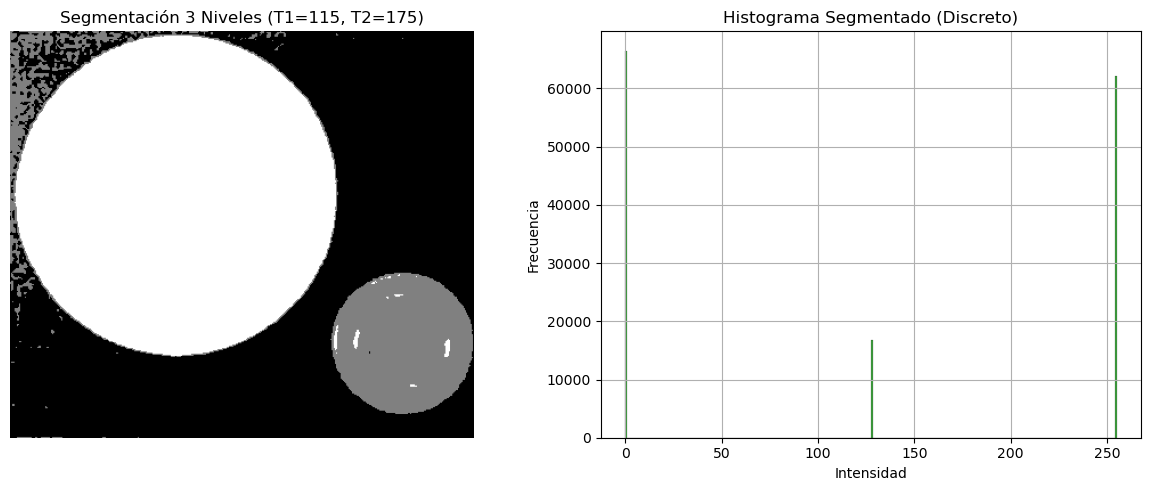

In [ ]:
thresholded_img = img.copy()

# Choose your thresholds and class values based on the histogram.
# Replace with your own values.

# Example for 3 levels (you may change the number of levels):
# Class 1: img < T1        -> V1
# Class 2: T1 <= img < T2  -> V2
# Class 3: img >= T2       -> V3

# T: Threshold
# V: Value

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'img' is already loaded from the previous exercise
# If you need to reload it:
# img = cv2.imread(images_path + 'plates.png', cv2.IMREAD_GRAYSCALE)

thresholded_img = img.copy()

# Define Thresholds (T) based on histogram valleys (theory)
T1 = 115  # Separates background from shadow
T2 = 175  # Separates shadow from plate

# Define Values (V) for each class (0=Black, 128=Gray, 255=White)
V1 = 0
V2 = 128
V3 = 255

# Apply multilevel thresholding
# Class 1: Background
thresholded_img[img < T1] = V1

# Class 2: Shadows/Edges (Between T1 and T2)
thresholded_img[(img >= T1) & (img < T2)] = V2

# Class 3: Plates (Greater than T2)
thresholded_img[img >= T2] = V3

# -------------------------------------------------------------------------
# Visualization
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 5))

# 1. Segmented Image
plt.subplot(1, 2, 1)
plt.imshow(thresholded_img, cmap='gray')
plt.title(f'3-Level Segmentation (T1={T1}, T2={T2})')
plt.axis('off')

# 2. Resulting Histogram
plt.subplot(1, 2, 2)
# We use bins=256 to clearly see that there are only 3 bars
sns.histplot(thresholded_img.reshape(-1), bins=256, color='green')
plt.title('Segmented Histogram (Discrete)')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

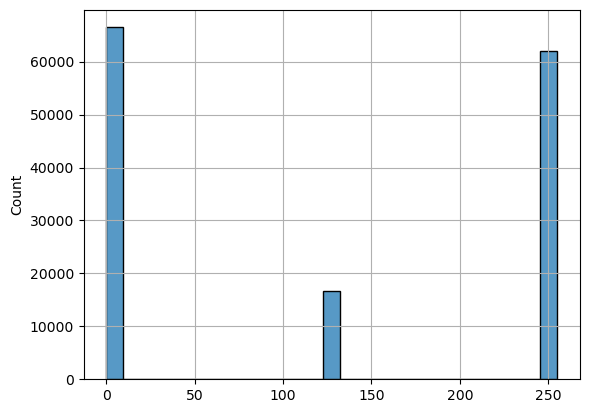

In [14]:
sns.histplot(thresholded_img.reshape(-1))
plt.show()

**Exercise 3 (0.05 pts):**
Read and visualize the image 'avocado.png', and:
1. Check the bimodal distribution of the pixels.
1. What intensity threshold would you use to segment the avocado?
1. Segment the image using the Otsu method.
   What is the estimated optimal threshold?

**Key Concepts**

***Otsu Method***: The Otsu method is used to perform automatic image
thresholding in order to separate an image into foreground and background.
It works by choosing the threshold that minimizes the intra-class variance
(or maximizes the inter-class variance) of the pixel intensities, meaning,
it finds the value that best separates the two classes.

Min pixel value = 4
Max pixel value = 255


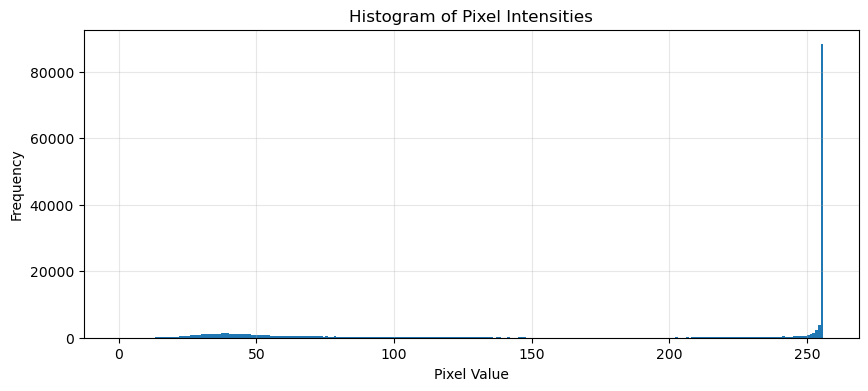

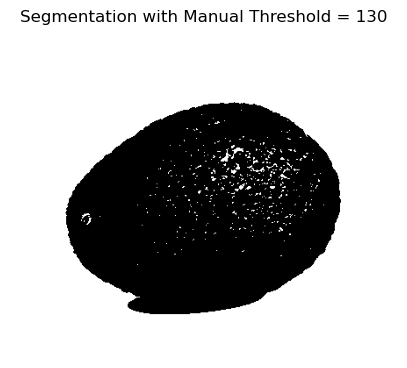

In [15]:
# Load and visualize 'avocado.png' in grayscale and inspect its histogram.
# Inspect the minimum and maximum pixel values
#    Ex.: np.min(img) and np.max(img)
# Plot the histogram of pixel intensities
# Given the histogram, decide where you would place a manual threshold to separate the avocado from the background

#YOUR CODE HERE
# img = cv2.imread(...)
#if img is None:
#    (...)
#print('Min and max pixel value =',np.min(...), ',',np.max(...))
#(...)

import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image in grayscale
img = cv2.imread('./images/avocado.png', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # Inspect the minimum and maximum pixel values
    print('Min pixel value =', np.min(img))
    print('Max pixel value =', np.max(img))

    # Plot the histogram of pixel intensities to decide the threshold
    plt.figure(figsize=(10, 4))
    plt.hist(img.ravel(), 256, [0, 256])
    plt.title('Histogram of Pixel Intensities')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- MANUAL THRESHOLD CALCULATION ---
    # Based on the histogram above, look for the valley between the two peaks.
    # Replace '100' with the value you observe in the plot.
    manual_threshold = 130
    
    # Apply the manual threshold to segment the image
    # Pixels > manual_threshold will be set to 255 (white), others to 0 (black)
    _, segmented_img_manual = cv2.threshold(img, manual_threshold, 255, cv2.THRESH_BINARY)

    # Visualize the result
    plt.figure(figsize=(5, 5))
    plt.imshow(segmented_img_manual, cmap='gray')
    plt.title(f'Segmentation with Manual Threshold = {manual_threshold}')
    plt.axis('off')
    plt.show()

else:
    print("Error: Image 'avocado.png' not found. Check the path.")





Otsu's thresholding

Estimated optimal threshold = 153.0


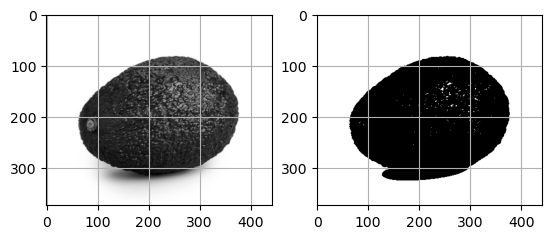

In [16]:
threshold, thresholded_img = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
print('Estimated optimal threshold =', threshold)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(thresholded_img, cmap='gray')
plt.show()

**Exercise 4 (0.05):**
Read and visualize the image 'CT.png', and:
1. Inspect the intensity distribution of the pixels.
1. What intensity threshold would you use to segment the lungs? 60.0
1. Try to segment the lungs using the Otsu method.
   What is the estimated optimal threshold? 51.0

Min pixel value = 0
Max pixel value = 198


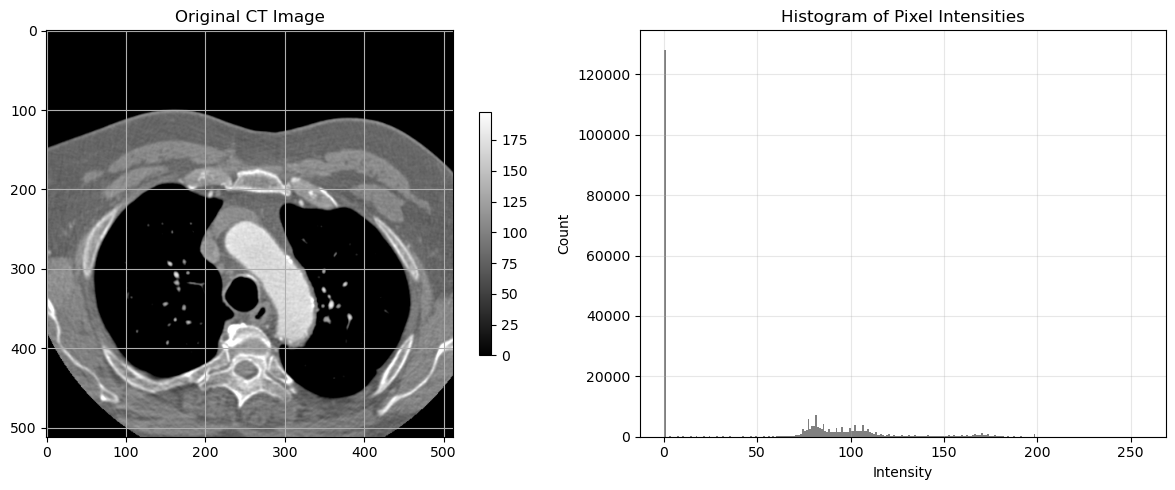

Manual Threshold selected: 60


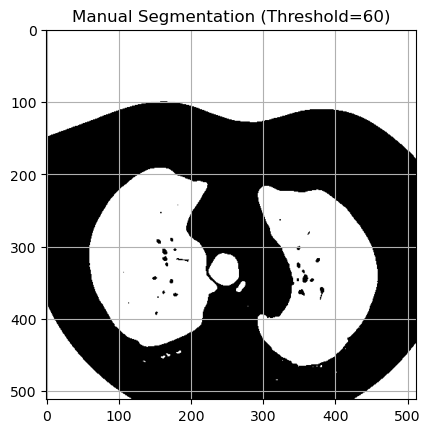

In [17]:
# Inspect the intensity distriibution of 'CT.png'
# Propose a manual threshold for segmenting the lungs based on the histogram
# Apply it and visualize the result

import cv2
import numpy as np
from matplotlib import pyplot as plt
import sys

# 1. Load the image
img_path = './images/CT.png'  # Check your path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
  sys.exit('Input image not found, check the path')

# 2. Inspect intensity distribution (Histogram)
print('Min pixel value =', np.min(img))
print('Max pixel value =', np.max(img))

plt.figure(figsize=(12, 5))

# Plot Image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original CT Image')
plt.colorbar(shrink=0.6)

# Plot Histogram
plt.subplot(1, 2, 2)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Pixel Intensities')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3. Manual Segmentation
# ---------------------------------------------------------------------
# We want to segment the lungs (dark pixels).
# Based on the histogram, we choose a threshold in the valley between 
# the dark peak (air) and the gray peak (tissue).
manual_thr = 60  # <--- ADJUST THIS VALUE based on the histogram observation

print(f"Manual Threshold selected: {manual_thr}")

# We use THRESH_BINARY_INV because we want the DARK pixels (lungs) to be white (255)
# Logic: If pixel < manual_thr -> 255 (Foreground/Lungs), Else -> 0 (Background)
_, manual_seg = cv2.threshold(img, manual_thr, 255, cv2.THRESH_BINARY_INV)

# Visualize the result
plt.figure()
plt.imshow(manual_seg, cmap='gray')
plt.title(f'Manual Segmentation (Threshold={manual_thr})')
plt.show()

Otsu's thresholding

Estimated optimal threshold (Otsu) = 51.0


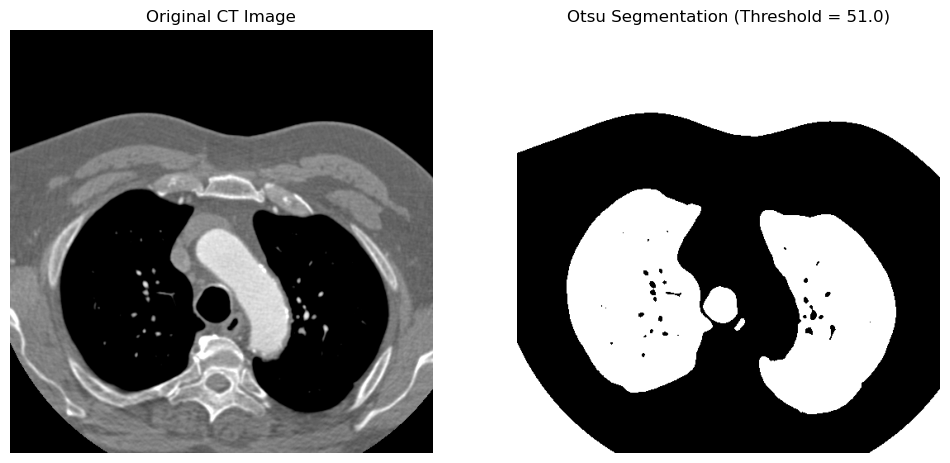

In [18]:
# Apply Otsu's method as in exercise 4 to compare both segmentations.

# We use THRESH_BINARY_INV + THRESH_OTSU because the lungs are dark (air) 
# and we want them to be the foreground (white) in the mask.
otsu_threshold, otsu_seg = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f'Estimated optimal threshold (Otsu) = {otsu_threshold}')

# Visualize the comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original Image
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original CT Image')
ax[0].axis('off')

# Otsu Segmentation
ax[1].imshow(otsu_seg, cmap='gray')
ax[1].set_title(f'Otsu Segmentation (Threshold = {otsu_threshold})')
ax[1].axis('off')

plt.show()

**Exercise 5 (0.10 pts):** Using the auxiliary functions provided next:
1. Apply the Gaussian Mixture Model (GMM) method
   (e.g. the implementation in scikit-learn)
   to 'CT.png' to segment **other parts** of the image.
   First exclude the background and the lungs
   and try different number of Gaussians.
1. Would it be possible to additionally segment the bones (whitest parts)? 

In a CT scan, bones are the densest and brightest structures (highest pixel values, located on the far right of the histogram). By fitting a GMM with enough components (e.g., $k=3$ or $k=4$), the algorithm will assign one of the Gaussians specifically to these high values (the Gaussian with the highest mean $\mu$). To segment the bones, we would simply select the pixels that have the highest probability of belonging to that specific Gaussian.

**Key Concepts**

***Gaussian Mixture Model (GMM)***:
A Gaussian Mixture Model is a probabilistic model
that assumes all data points are generated from a mixture of
a finite number of Gaussian distributions with certain parameters.

Some helper functions we use later.

In [19]:
def fit_GMM(img, nb_gaussians, plot_stds=False):
  """ Fit GMM given the desired number of Gaussians. """

  gmm = mixture.GaussianMixture(n_components=nb_gaussians, max_iter=1000, covariance_type='full', random_state=1).fit(img.reshape(-1, 1))
  ordered_mu, ordered_std, ordered_pi, order = find_GMM_statistics(gmm)
  gaussian_colors = ['b','g','r','c','m','y']    # max 6 gaussians, add more if necessary
  print('Means = ', ordered_mu)
  print('Stds = ', ordered_std)
  print('Pis = ', ordered_pi)
  for i in range(nb_gaussians):
    plot_gaussian_and_stds(np.array([np.min(img), np.max(img)]), ordered_mu[i], ordered_std[i], ordered_pi[i], gaussian_colors[i], plot_stds, alpha=0.8)

  return gmm, ordered_mu, ordered_std, ordered_pi, order

def find_GMM_statistics(gmm):
  """ Determine which one is the first (lower mean),
      the second, the third, etc.  Gaussian to consistently color
      them in the plots,
      visualize the masks, etc. """

  all_means = np.array(gmm.means_[:, 0]).flatten()
  all_covariances = gmm.covariances_.flatten()

  order = np.argsort(all_means)  # this is also the label of clusters, return also 'order', useful to modify the cluster's label if necessary
  ordered_mu = all_means[order]
  ordered_std = np.sqrt(all_covariances[order])
  ordered_pi = gmm.weights_[order]

  return ordered_mu, ordered_std, ordered_pi, order

def plot_gaussian_and_stds(gaussians_range, mu, std, pi, color, plot_stds=False, alpha=1):
  """ Plot the Gaussian given by mu, std and pi.
      If plot_stds, additionally plot vertical lines corresponding to
      +-1SD, +-2SD, +-3SD """

  xmin, xmax = gaussians_range
  x = np.linspace(xmin, xmax, 1000)
  p = norm.pdf(x, mu, std) * pi
  if plot_stds:
      # plt.axvline(mu + std, 0, 1, label='pyplot vertical line', c=color)
    plt.axvline(mu + std, 0, 1, c=color, ls='--', alpha=0.75)
    plt.axvline(mu - std, 0, 1, c=color, ls='--', alpha=0.75)

    plt.axvline(mu + 2 * std, 0, 1, c=color, ls='-.', alpha=0.5)
    plt.axvline(mu - 2 * std, 0, 1, c=color, ls='-.', alpha=0.5)

    plt.axvline(mu + 3 * std, 0, 1, c=color, ls=':', alpha=0.25)
    plt.axvline(mu - 3 * std, 0, 1, c=color, ls=':', alpha=0.25)

    plt.plot(x, p, color, linewidth=2, alpha=alpha,
      label="Mean = {:.2f}; STD = {:.2f}; Weight = {:.2f}".format(mu, std, pi))

Means =  [ 0.         98.01459654]
Stds =  [1.00000000e-03 3.22300677e+01]
Pis =  [0.66329405 0.33670595]


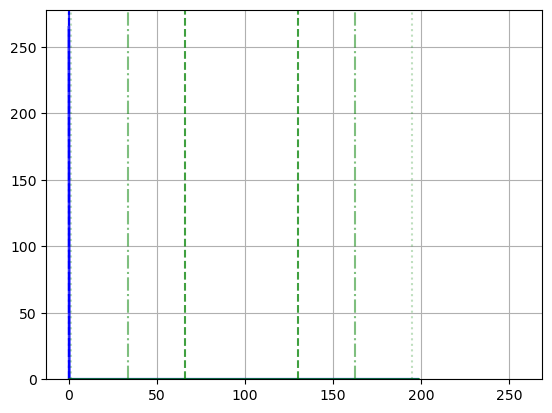

Means =  [  0.          88.06644761 166.57663669]
Stds =  [1.00000000e-03 1.97418048e+01 1.13603936e+01]
Pis =  [0.66329416 0.29404119 0.04266465]


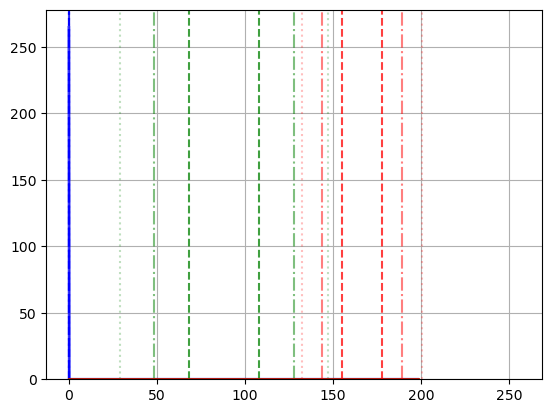

Means =  [  0.          85.83298041 106.65996245 166.15825235]
Stds =  [1.00000000e-03 1.95005277e+01 4.68804537e+00 1.17476598e+01]
Pis =  [0.66329416 0.2637267  0.02958804 0.0433911 ]


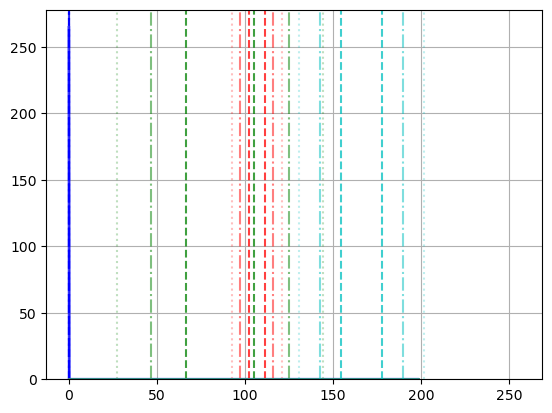

In [20]:
other_colors = img[np.where(thresholded_img==255)]      # exclude background and lungs
plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True)    # density for probability density instead of total count

gmm, ordered_mu, ordered_std, ordered_pi, order=fit_GMM(other_colors, nb_gaussians=2, plot_stds=True)
plt.show()

plt.figure()
plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True)
gmm, ordered_mu, ordered_std, ordered_pi, order=fit_GMM(other_colors, nb_gaussians=3, plot_stds=True)
plt.show()

plt.figure()
plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True)
gmm, ordered_mu, ordered_std, ordered_pi, order=fit_GMM(other_colors, nb_gaussians=4, plot_stds=True)
plt.show()

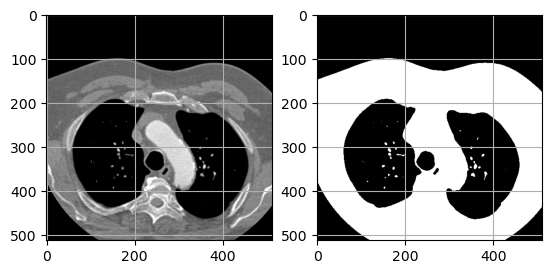

In [21]:
threshold = 50

mask = np.zeros_like(img)
mask[np.where(img > threshold)] = 1

fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(mask, cmap='gray')
plt.show()

Means =  [ 92.00873646 157.66226977]
Stds =  [13.76947058 19.99808484]
Pis =  [0.83491128 0.16508872]


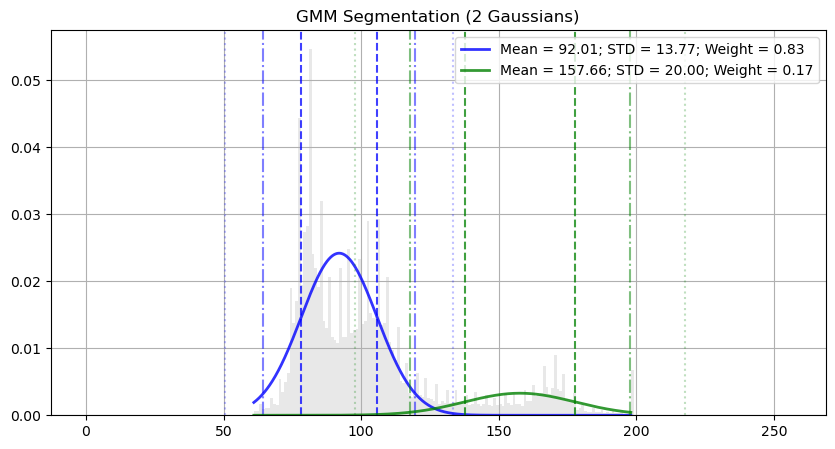

Means =  [ 80.85447484 103.26768448 157.10160637]
Stds =  [ 5.90147829  9.05724362 20.16061991]
Pis =  [0.42394259 0.40736036 0.16869706]


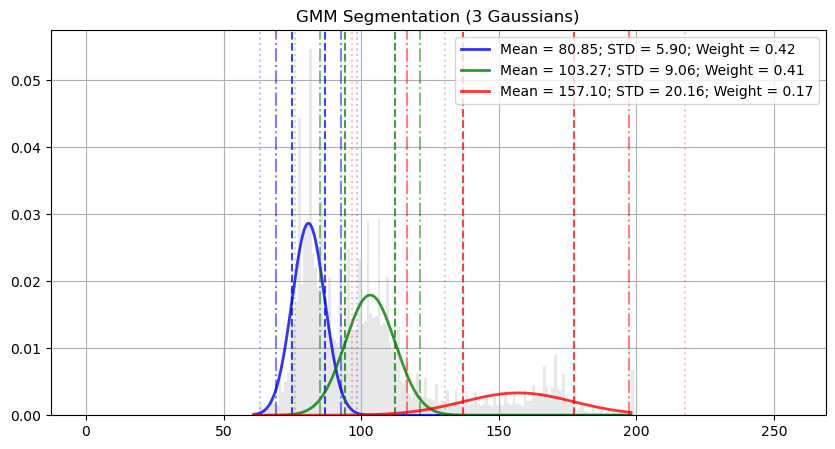

Means =  [ 81.17211553 102.96700712 129.27389615 167.83000099]
Stds =  [ 6.0462928   7.3217149  11.21054908 13.17649591]
Pis =  [0.44490598 0.36075886 0.07853736 0.11579779]


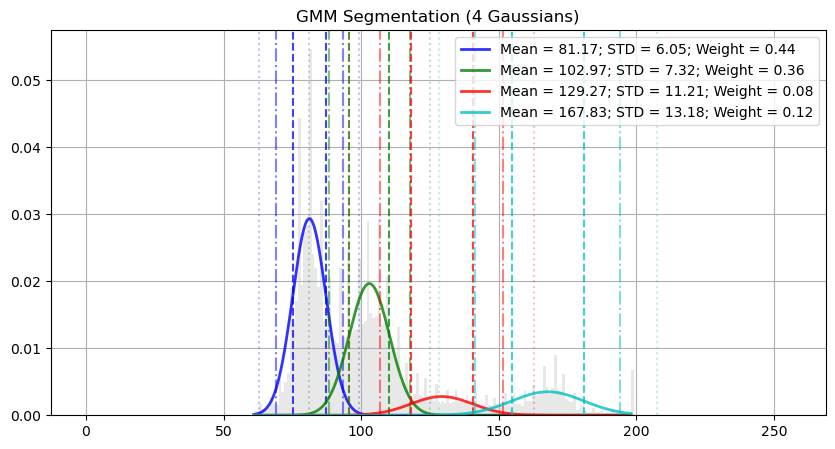

In [22]:
# -------------------------------------------------------------------------
# EXERCISE 5: MAIN EXECUTION
# -------------------------------------------------------------------------

# 1. Load image
img = cv2.imread('./images/CT.png', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 2. Pre-processing: Exclude background and lungs
    # We established in Ex 4 that a threshold around 60 separates air/lungs from body.
    threshold = 60
    
    # We extract only the pixels belonging to the body (soft tissue + bone)
    # This removes the large peak at 0 (background/air) from the analysis
    other_colors = img[img > threshold]

    # 3. Apply GMM with different number of Gaussians (2, 3, 4)
    
    # --- Case k=2 ---
    plt.figure(figsize=(10, 5))
    # Plot normalized histogram of the body data (density=True)
    plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    plt.title("GMM Segmentation (2 Gaussians)")
    # Fit GMM and plot
    gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=2, plot_stds=True)
    plt.legend()
    plt.show()

    # --- Case k=3 ---
    plt.figure(figsize=(10, 5))
    plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    plt.title("GMM Segmentation (3 Gaussians)")
    gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=3, plot_stds=True)
    plt.legend()
    plt.show()

    # --- Case k=4 ---
    # With 4 Gaussians, one of them usually isolates the bones (highest mean) very well
    plt.figure(figsize=(10, 5))
    plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    plt.title("GMM Segmentation (4 Gaussians)")
    gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=4, plot_stds=True)
    plt.legend()
    plt.show()

else:
    print("Error: Image 'CT.png' not found.")

#### Clustering

**Exercise 6 (0.05 pts):** Using 'CT.png':
1. Try **several times** k-means specifying a different number of clusters.
1. What differences, if any, do you observe between each run?

As the number of clusters ($k$) increases, the algorithm segments the image into more granular levels of detail. A lower $k$ only separates the regions with high contrast (e.g., background vs. foreground), while a higher $k$ allows the model to differentiate between tissues or materials with more similar intensity values.

**Key Concepts**

***K-means***: K-means is an iterative clustering algorithm
that groups similar data points together
based on their distance to a central point, called the centroid.
The centroids represents the centers of the clusters
and are calculated as the means (or medians) of the points in the cluster.

We use the functions as imported from the scikit-learn library.

Define a convenience function to compute and show the k-means results.

In [23]:
def RunKMeans(img,k):
  kmeans = KMeans(n_clusters=k, n_init="auto").fit(img.reshape(-1, 1))
  fig, ax = plt.subplots(1, 2)
  ax[0].imshow(img, cmap='gray')
  ax[1].imshow(kmeans.labels_.reshape(img.shape))
  # plot image + labels overlayed
  plt.figure()
  plt.imshow(img, cmap='gray')
  plt.imshow(kmeans.labels_.reshape(img.shape), alpha=0.2)
  plt.colorbar()
  plt.show()

In [24]:
# Run k-means three times with different values of k (for example k=2, 3, 4)
# For each k, visualize the label mage and the overlay

#Example:
#RunKMeans(img, 2)

Run 1

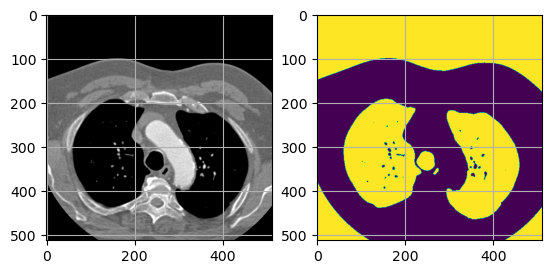

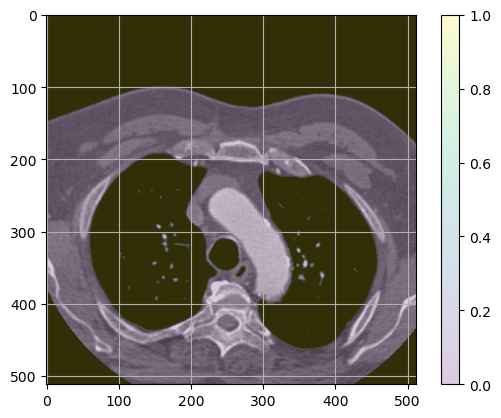

In [25]:
# Run K-means with k=2
# Expected: Separation between Air (lungs/background) and Body (tissue/bone)
RunKMeans(img, 2)

Run 2

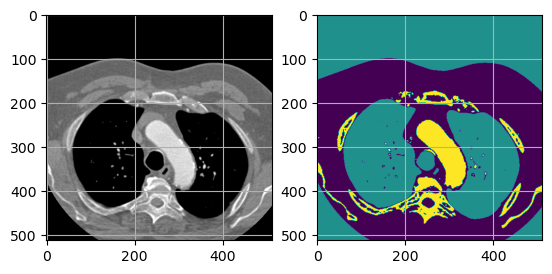

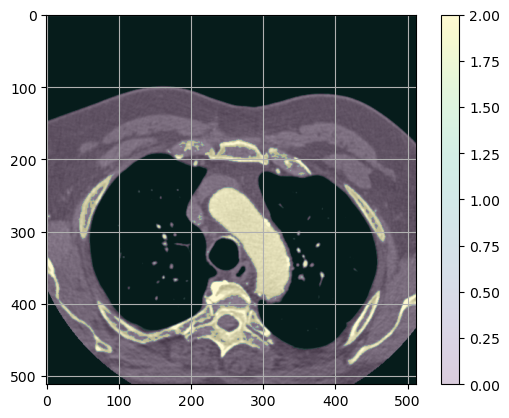

In [26]:
# Run K-means with k=3
# Expected: Separation of Air, Soft Tissue, and Bone
RunKMeans(img, 3)

Run 3

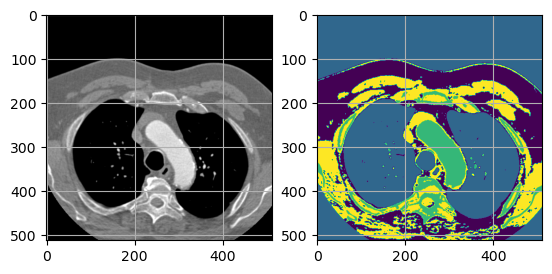

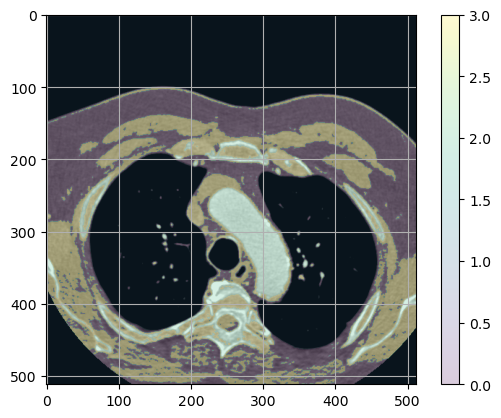

In [27]:
# Run K-means with k=4
# Expected: Further subdivision (e.g., separating background air from lung air, or different tissue densities)
RunKMeans(img, 4)

**Exercise 7 (0.05 pts):**
Read and visualize 'puncher.png' and its corresponding histogram. Then:
1. Apply k-means to segment the object.
1. Apply Meanshift to segment the object. Try different 'bandwidth' values.

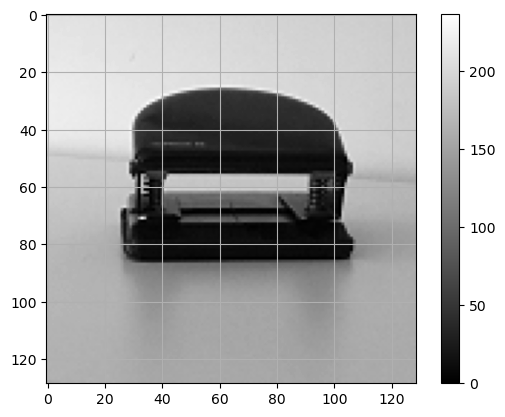

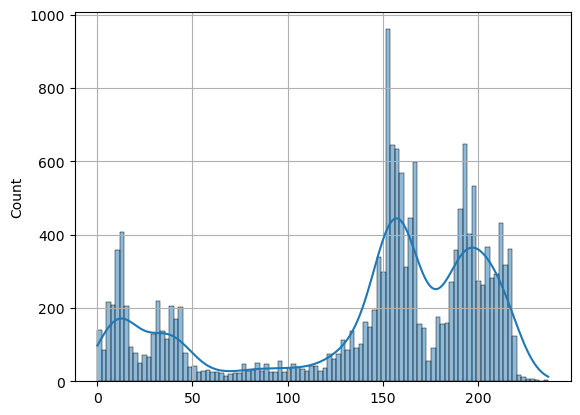

In [50]:
img = cv2.imread(images_path + 'puncher.png', cv2.IMREAD_GRAYSCALE)
if img is None:
  sys.exit('Input image not found, check the path')

plt.imshow(img, cmap='gray')
plt.colorbar()
plt.figure()
sns.histplot(img.reshape(-1), bins=100, kde=True)
plt.show()

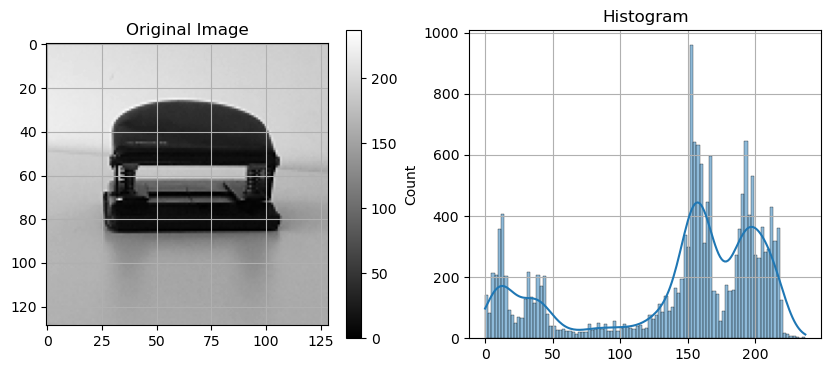

--- K-Means Segmentation ---


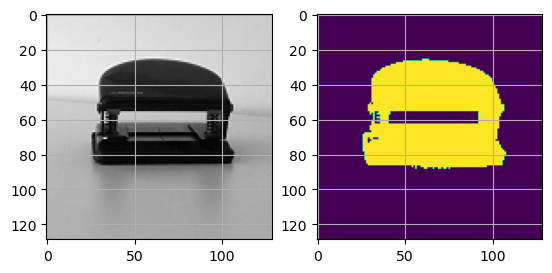

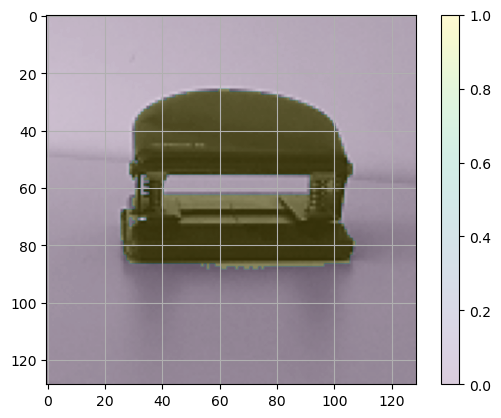

In [53]:
#Apply K-means (calling RunKMeans) to segment the object from the background, try with k=2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, MeanShift

# 1. Load and visualize image and histogram
img = cv2.imread(images_path + 'puncher.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    sys.exit('Input image not found, check the path')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.colorbar()

plt.subplot(1, 2, 2)
sns.histplot(img.reshape(-1), bins=100, kde=True)
plt.title("Histogram")
plt.show()

# ---------------------------------------------------------
# PART 1: Apply K-means (k=2)
# ---------------------------------------------------------
print("--- K-Means Segmentation ---")
# Apply K-means to segment the object from the background (2 clusters)
RunKMeans(img, 2)



Meanshift with default bandwidth (this might take some time, be patient).

Found 2 clusters


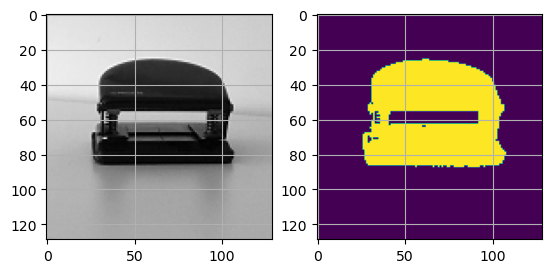

In [54]:
ms_default = MeanShift().fit(img.reshape(-1, 1))

print('Found', len(np.unique(ms_default.labels_)), 'clusters')
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(ms_default.labels_.reshape(img.shape))
plt.show()

Meanshift with different bandwidths.
We first define a convenience function to run experiments more easily.

In [51]:
def RunMeanShift(img, bw):
  ms = MeanShift(bandwidth=bw).fit(img.reshape(-1, 1))
  print('Found', len(np.unique(ms.labels_)), 'clusters')
  fig, ax = plt.subplots(1, 2)
  ax[0].imshow(img, 'gray')
  ax[1].imshow(ms.labels_.reshape(img.shape))
  plt.show()

--- MeanShift (Default Bandwidth) ---
Running default MeanShift... this might take a moment.
Found 2 clusters with default bandwidth


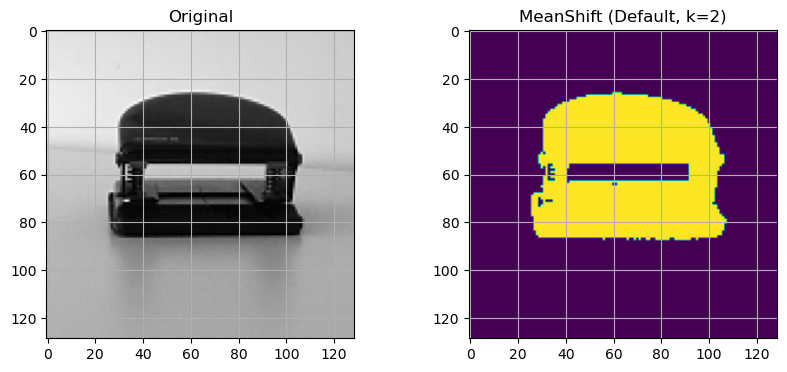

--- MeanShift Experiments (Varying Bandwidth) ---
Bandwidth = 5 -> Found 17 clusters


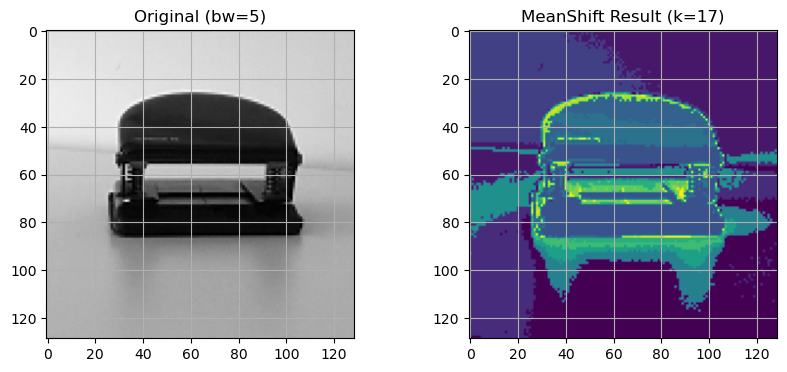

Bandwidth = 25 -> Found 3 clusters


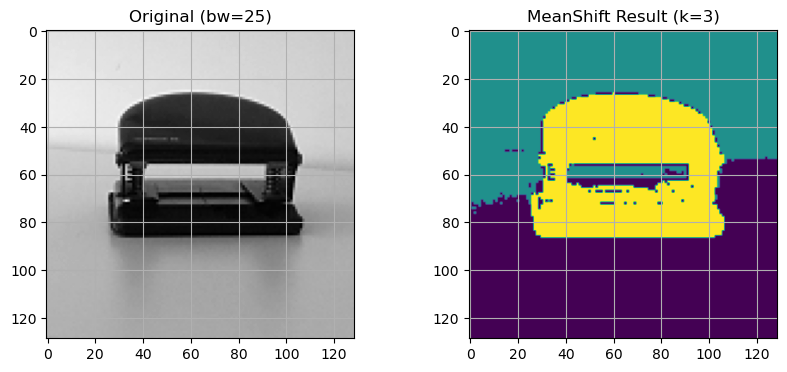

In [ ]:
# Using the RunMeanShift function defined above, run MeanShift with at least two different bandwidth values (e.g. 5, 10, 20)

# ---------------------------------------------------------
# PART 3: MeanShift with Different Bandwidths
# ---------------------------------------------------------
def RunMeanShift(img, bw):
    # Flatten image for clustering
    flat_img = img.reshape(-1, 1)
    
    # Run MeanShift with specified bandwidth
    ms = MeanShift(bandwidth=bw, bin_seeding=True).fit(flat_img)
    
    # Check number of clusters found
    n_clusters = len(np.unique(ms.labels_))
    print(f'Bandwidth = {bw} -> Found {n_clusters} clusters')
    
    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title(f'Original (bw={bw})')
    ax[1].imshow(ms.labels_.reshape(img.shape), cmap='viridis')
    ax[1].set_title(f'MeanShift Result (k={n_clusters})')
    plt.show()

print("--- MeanShift Experiments (Varying Bandwidth) ---")
# Run MeanShift with at least two different bandwidth values
# Small bandwidth (e.g., 5) -> Expect many clusters (over-segmentation)
RunMeanShift(img, 5)

# Medium/Large bandwidth (e.g., 25) -> Expect fewer clusters (better object separation)
RunMeanShift(img, 25)


**Exercise 8 (0.25 pts):**
Now we work with an example that uncovers some of the short-commings
of the methods seen so far. Our goal is to separate the foreground
of a not so well taken photograph of a sudoku game.
Naturally, we consider as foreground the numbers and the gridlines.

In [55]:
img = cv2.imread(images_path + 'sudoku.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
  sys.exit('Input image not found, check the path')

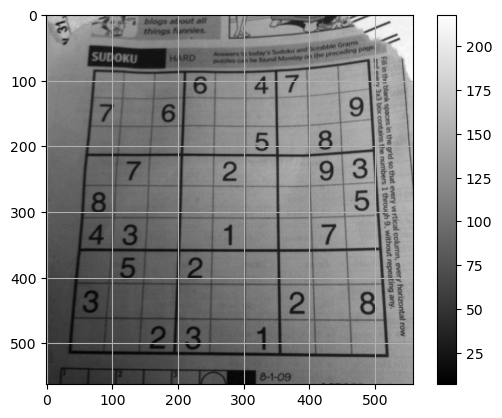

In [56]:
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

We calculate the histogram and visualize it using matplotlib and pyplot.


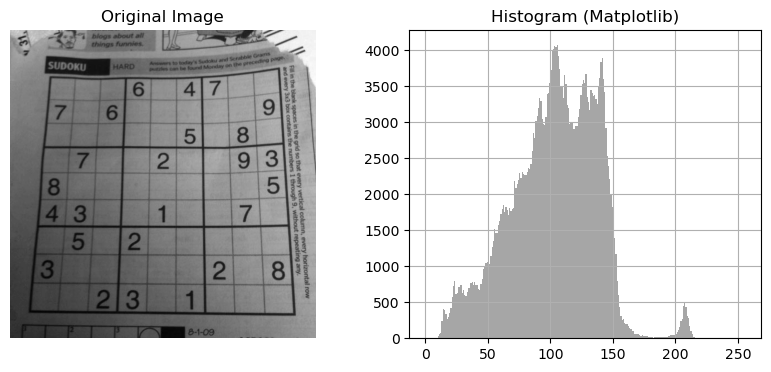

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if img is None:
    print("Error: 'sudoku.jpg' not found.")
else:
    # Visualization & Histogram
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # Calculate histogram with matplotlib
    plt.subplot(1, 2, 2)
    plt.hist(img.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
    plt.title('Histogram (Matplotlib)')
    plt.show()

We do the same using the “seaborn” package.

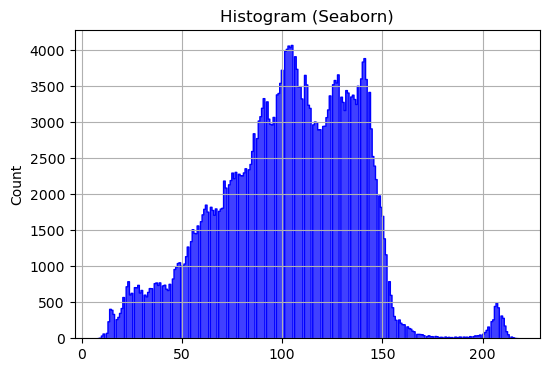

In [59]:
if img is not None:
    plt.figure(figsize=(6, 4))
    sns.histplot(img.ravel(), bins=256, color='blue', element='step')
    plt.title('Histogram (Seaborn)')
    plt.show()

We compute a smoothed version of the histogram using KDE from the
“seaborn” package.

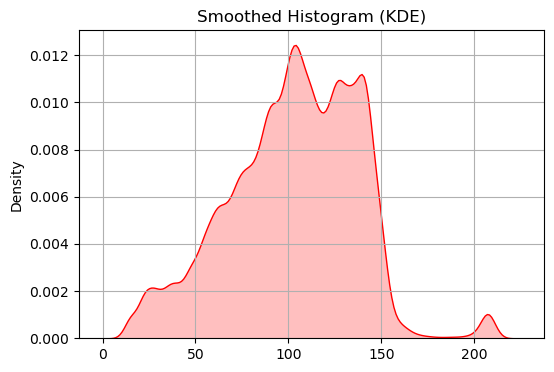

In [60]:
if img is not None:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(img.ravel(), fill=True, color='red')
    plt.title('Smoothed Histogram (KDE)')
    plt.show()

Apply global thresholding to 'sudoku.jpg'.
Can you find a number of levels to separate the foreground
(i.e. the numbers and the gridlines)?

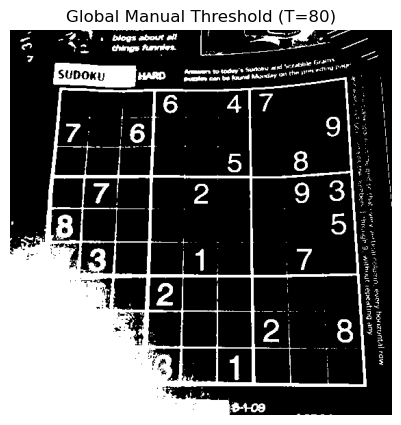

In [61]:
#Try to separate the foreground (digits and grid lines) from the background. You can refresh your memory by looking at exercise 2

if img is not None:
    # Try to find a manual threshold. Due to uneven lighting, it's impossible to find one perfect value.
    # Let's try an intermediate value, e.g., 80.
    manual_thr = 80
    _, manual_seg = cv2.threshold(img, manual_thr, 255, cv2.THRESH_BINARY_INV)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(manual_seg, cmap='gray')
    plt.title(f'Global Manual Threshold (T={manual_thr})')
    plt.axis('off')
    plt.show()



Let's try Otsu's thresholding.

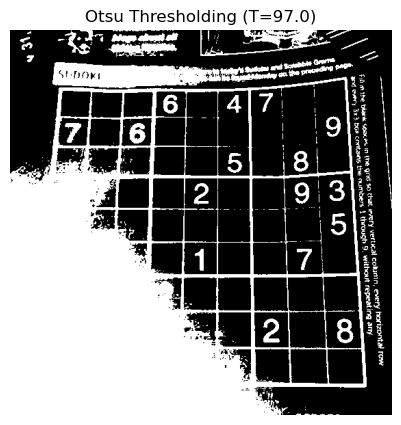

In [62]:
#Apply Otsu's method (revisit exercise 3 and 4) 

if img is not None:
    otsu_thr, otsu_seg = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(otsu_seg, cmap='gray')
    plt.title(f'Otsu Thresholding (T={otsu_thr:.1f})')
    plt.axis('off')
    plt.show()


How do you rate the performance of Otsu's thresholding?

Let's try with Gaussian Mixture Model. What would be a good number of Gaussians to model the data?

Means =  [ 57.43406888  98.6182309  128.5765972 ]
Stds =  [21.60710225 18.14260034 22.18361472]
Pis =  [0.22379659 0.34286453 0.43333888]


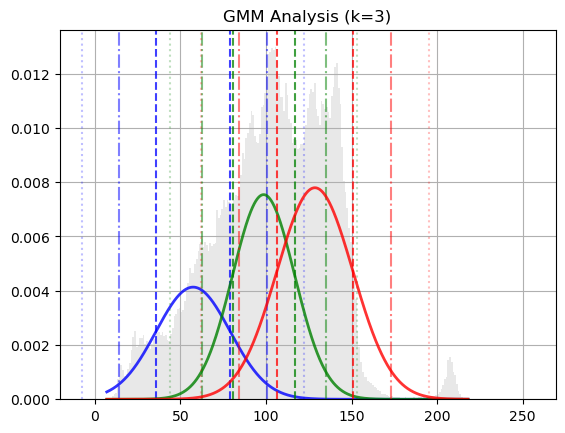

In [63]:
if img is not None:
    # GMM also struggles because intensity distributions overlap globally.
    plt.figure()
    plt.title("GMM Analysis (k=3)")
    # We use density=True to match GMM output scale
    plt.hist(img.ravel(), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    
    # Assuming fit_GMM is defined from previous exercises
    try:
        fit_GMM(img, nb_gaussians=3, plot_stds=True) 
    except NameError:
        print("Function 'fit_GMM' not defined. Please run Exercise 5 cells first.")
        
    plt.show()

Does the GMM fit our needs here?

Let's try with k-means. What number of clusters would you choose?

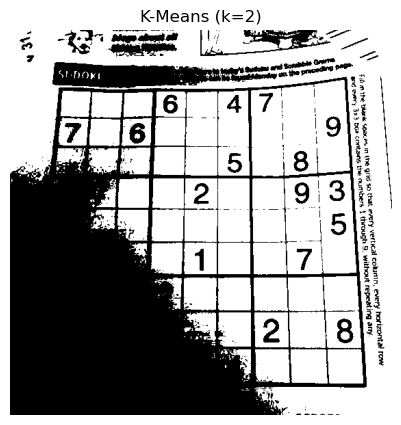

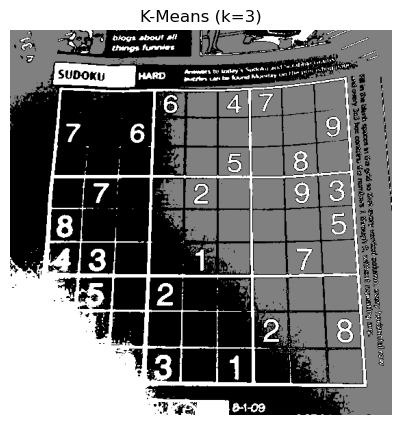

In [64]:
#Run K-means with several values of k
# Based on the reults, what number of clusters would you choose and why?

from sklearn.cluster import KMeans

def RunKMeans(image, k):
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42).fit(image.reshape(-1, 1))
    segmented = kmeans.labels_.reshape(image.shape)
    plt.figure(figsize=(5, 5))
    plt.imshow(segmented, cmap='gray')
    plt.title(f'K-Means (k={k})')
    plt.axis('off')
    plt.show()

if img is not None:
    # Try k=2 (Background vs Foreground)
    RunKMeans(img, 2)
    # Try k=3 to see if shadows get their own cluster
    RunKMeans(img, 3)



Let's try with meanshift.
(This might take even more time compared to above.)

Running MeanShift... (this may take a while)


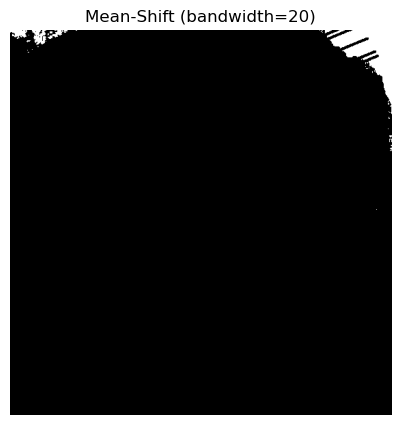

In [65]:
#Run MeanShift wirh a bandwidth of 6 and inspect the result.

from sklearn.cluster import MeanShift

if img is not None:
    print("Running MeanShift... (this may take a while)")
    # We use a bandwidth of 20 as requested/suggested for reasonable speed/result
    ms = MeanShift(bandwidth=20, bin_seeding=True).fit(img.reshape(-1, 1))
    
    plt.figure(figsize=(5, 5))
    plt.imshow(ms.labels_.reshape(img.shape), cmap='gray')
    plt.title('Mean-Shift (bandwidth=20)')
    plt.axis('off')
    plt.show()



How do these two methods handle the problem?

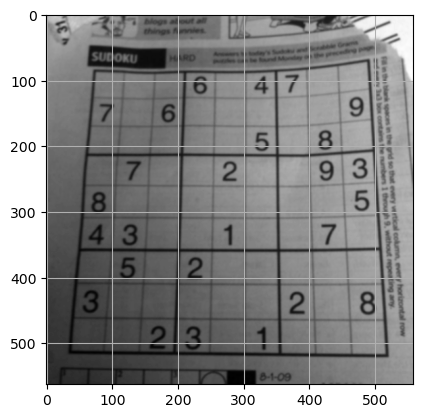

In [43]:
#Finally, try Gaussian blur and adaptative thresholding on 'sudoku,jpg'

blurred_img = cv2.GaussianBlur(img, (5,5), 0)
plt.imshow(blurred_img, cmap='gray')
plt.show()

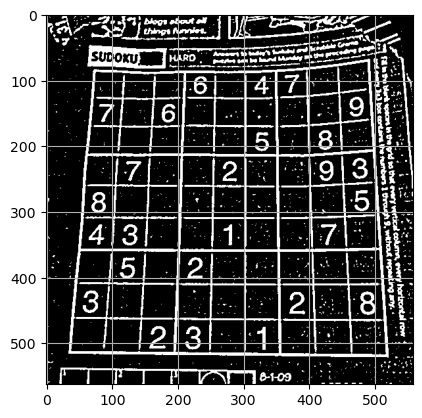

In [44]:
thresholded_img = cv2.adaptiveThreshold(blurred_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
plt.imshow(thresholded_img, cmap='gray')
plt.show()

1. Argue what this type of adaptive thresholding actually does.
1. Try to improve the chosen parameters.
1. Suggest how you would proceed to segment the foreground
   we are interested in.

### Answers:

**1. Can you find a number of levels to separate the foreground (global threshold)?**
No. Due to uneven lighting (shadows), any global threshold fails. A low threshold misses digits in shadows, while a high threshold treats the bright background as noise.

**2. How do you rate the performance of Otsu's thresholding?**
Poor. Otsu calculates a single global threshold. Since the histogram lacks two clearly separated peaks (foreground vs. background overlap), it cannot segment the image effectively.

**3. Argue what this type of adaptive thresholding actually does.**
Adaptive thresholding calculates a threshold for each pixel based on a small local region (block size). It determines if a pixel is darker *relative to its neighbors* rather than the global average. This cancels out illumination gradients, allowing edge detection in both bright and dark areas.

**4. Suggest how you would proceed to segment the foreground.**
The optimal pipeline is: **Gaussian Blur** (to reduce noise) $\rightarrow$ **Adaptive Thresholding** (to handle shadows) $\rightarrow$ **Morphological Operations** (Closing/Opening to refine lines).

**5. Based on the results, what number of clusters would you choose and why?**
Actually, none of the K-values provide good segmentation.
* **With $k=2$:** Uneven illumination causes the dark background in shadows to merge with the digits.
* **With $k \ge 3$:** K-means separates intensity bands (lighting gradients) rather than objects, mixing digits into these bands.

**Exercise 9 (0.05 pts):**
Read and visualize the image 'fieldWheat.png',
and use k-means (**with number of clusters=3**) to segment:
1. The field of wheat alone. Save the resulting image.
1. The whole sky (clear sky and clouds)

- **Note 1:** If more than 1 feature
  (e.g. 'R', 'G', and 'B' in a color image) is given,
  each feature should be given as a column.
- **Note 2:** Remember that different initializations may lead to
  different clusters.

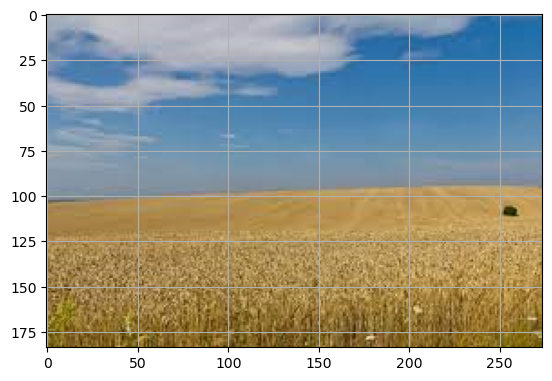

In [45]:
img = cv2.imread(images_path + 'field.png')      # cv2 reads it BGR order
if img is None:
  sys.exit('Input image not found, check the path')

plt.imshow(img[...,::-1])   # IMPORTANT --> matplotlib requires RGB order
plt.show()

In [46]:
X = np.array([img[:, :, 0].reshape(-1), img[:, :, 1].reshape(-1), img[:, :, 2].reshape(-1)]).T
print(X.shape)

(50416, 3)


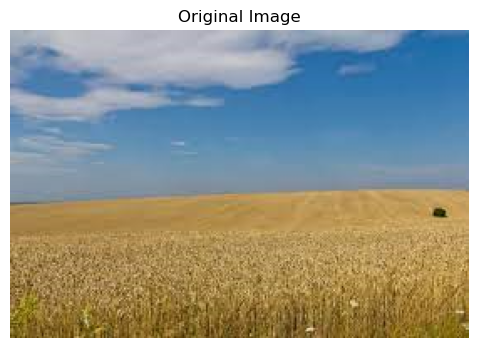

Dimensiones de los datos para clustering: (50416, 3)


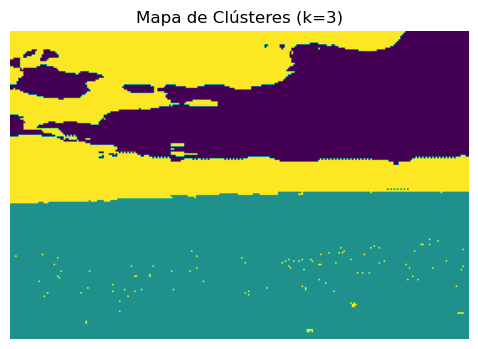

Centros de los clústeres (RGB):
Cluster 0: [ 73 128 174]
Cluster 1: [165 133  71]
Cluster 2: [144 160 177]


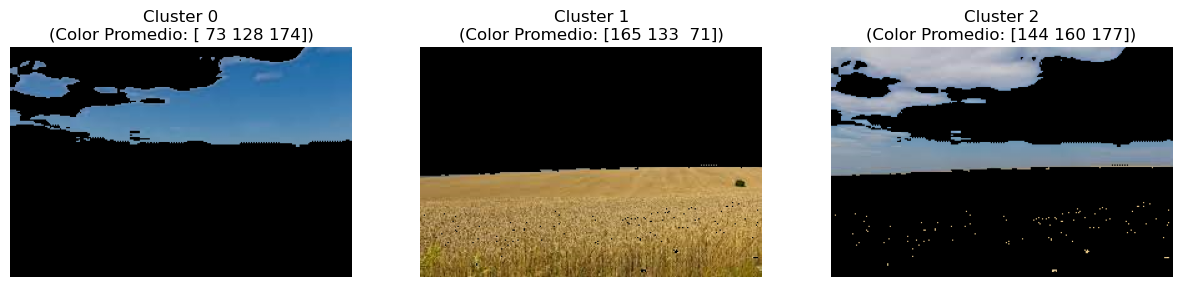

In [67]:
#  - Apply K-means with k = 3 to the RGB pixels in X.
#  - Reshape the labels to the image shape and visualize the cluster map.
#  - Overlay the clustering result on the original image.
#  - Inspect the cluster centers and decide which cluster corresponds to:
#       - The wheat field
#       - The sky (clear sky + clouds)
#       - Any remaining region


# YOUR CODE HERE
# Example steps (to be implemented by you):
# kmeans = KMeans(n_clusters=??, n_init="auto").fit(??)
# kmeans_labels = kmeans.labels_.reshape([img.shape[0], img.shape[1]])
# ...
#print(kmeans.cluster_centers_)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

if img is None:
    print("Error: No se encuentra la imagen (field.png o fieldWheat.png).")
else:
    # Convertir de BGR a RGB para visualizar correctamente con matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Visualizar imagen original
    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # 2. Preparar los datos para K-means
    # Aplanamos la imagen: (Alto * Ancho, 3 canales de color)
    X = img_rgb.reshape(-1, 3)
    print(f"Dimensiones de los datos para clustering: {X.shape}")

    # 3. Aplicar K-means con k=3
    k = 3
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    kmeans.fit(X)
    
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    # 4. Reconstruir la imagen de etiquetas
    # Redimensionamos las etiquetas (0, 1, 2) a la forma original de la imagen
    segmented_labels = labels.reshape(img_rgb.shape[:2])

    # Visualizar el mapa de clústeres
    plt.figure(figsize=(6, 4))
    plt.imshow(segmented_labels, cmap='viridis')
    plt.title(f"Mapa de Clústeres (k={k})")
    plt.axis('off')
    plt.show()

    # 5. Visualizar cada componente por separado (Overlay)
    print("Centros de los clústeres (RGB):")
    for i, center in enumerate(centers):
        print(f"Cluster {i}: {center.astype(int)}")

    plt.figure(figsize=(15, 5))
    for i in range(k):
        # Crear máscara para el clúster i
        mask = (segmented_labels == i).astype(np.uint8)
        
        # Aplicar máscara a la imagen original
        masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(masked_img)
        plt.title(f"Cluster {i}\n(Color Promedio: {centers[i].astype(int)})")
        plt.axis('off')
        
        # Para guardar la imagen del trigo (cuando identifiques cuál es):
        # Si visualmente el Cluster 1 es el trigo, descomenta la siguiente línea:
        # if i == 1: 
        #     cv2.imwrite('wheat_field_segmented.png', cv2.cvtColor(masked_img, cv2.COLOR_RGB2BGR))

    plt.show()


**Exercise 10 (0.15 pts): Density-based clustering**
1. Load 'matrix2.dat' data (data generated with 1 run of the code showed next. Note that each run will produce a different dataset. This is why we provide the file matrix2.dat, but you can generate different datasets and see how the clustering algorithm works on different situations).
1. Apply DBSCAN to segment the custers you observe.

In [72]:
# -----------------------------------------------------------------------------
# 1. Generate Data (To bypass loading error)
# -----------------------------------------------------------------------------
np.random.seed(42) # Ensure reproducibility
# Generating 3 clusters + noise as described in the notebook
X = np.concatenate((
    np.random.normal(0, 10, (50, 2)),    # Noise (wide dispersion)
    np.random.normal(3, 1, (250, 2)),    # Dense Cluster 1
    np.random.normal(10, 1, (400, 2)),   # Dense Cluster 2
    np.random.normal(-10, 2, (100, 2))   # Dense Cluster 3
))

First, let's see what k-means can do... You may need to adjust the number of clusters in the code.

c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


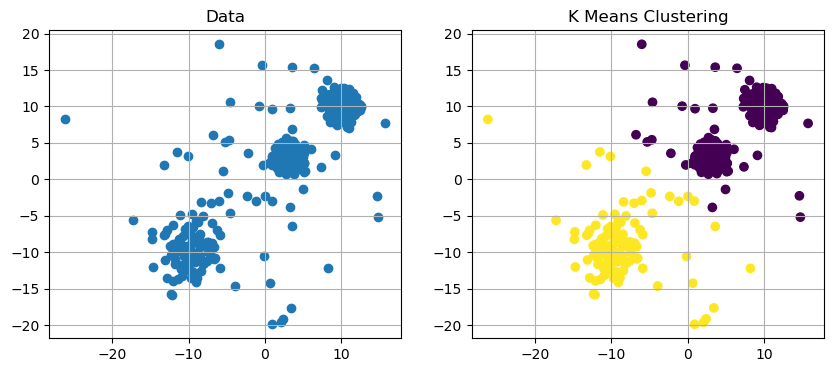

In [74]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].scatter(X[:, 0], X[:, 1])
ax[0].set_title("Data")

ax[1].scatter(X[:, 0], X[:, 1], c=kmeans_labels)
ax[1].set_title("K Means Clustering")
plt.show()

Now, let's apply density-based clustering with DBSCAN to see if we can improve the results.

In [71]:
clustering1 = DBSCAN().fit(X)      # default eps = 0.5, min_samples=5
print('Found', len(np.unique(clustering1.labels_))-1, 'clusters:', np.unique(clustering1.labels_))

clustering2 = DBSCAN(eps=3, min_samples=3).fit(X)
print('Found', len(np.unique(clustering2.labels_))-1, 'clusters:', np.unique(clustering2.labels_))

Found 7 clusters: [-1  0  1  2  3  4  5  6]
Found 4 clusters: [-1  0  1  2  3]


your bet:

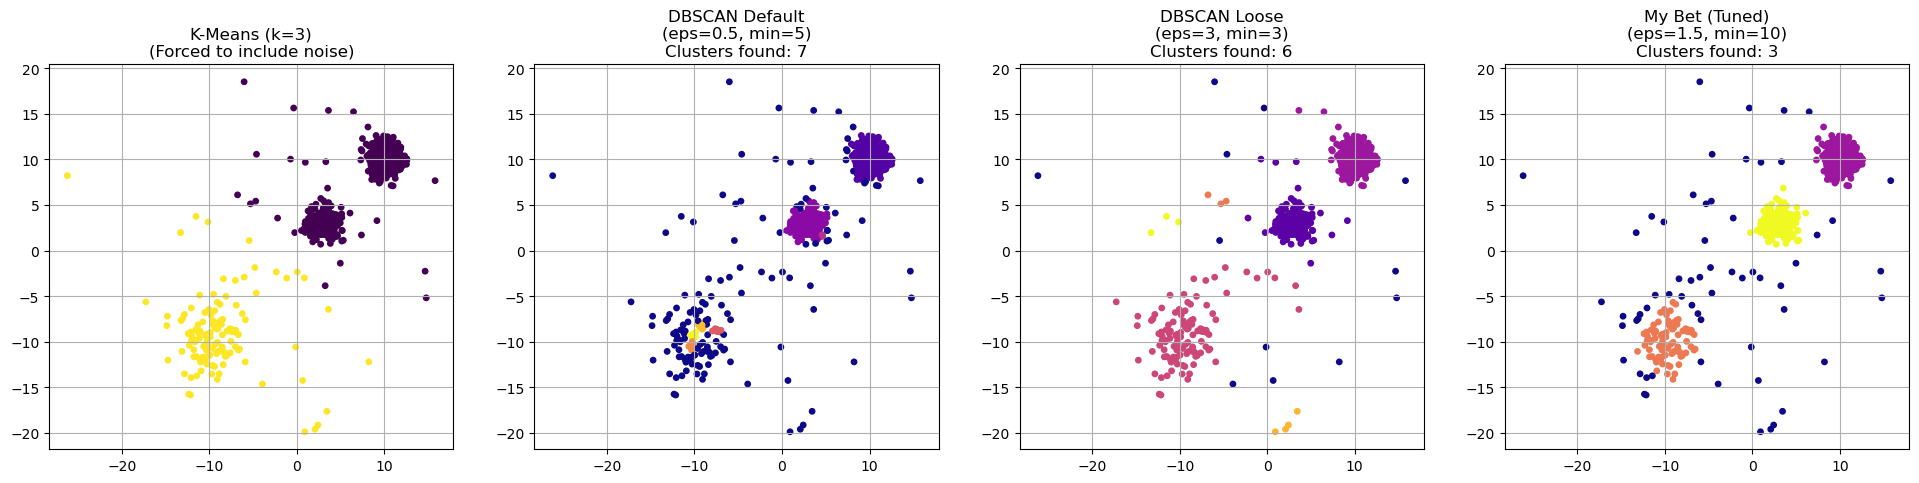

In [ ]:
# Choose values for eps and min_samples that you think might detect only the clearest clusters in the data.
# Fit DBSCAN with your parameters.
# Compare your results with clustering1 and clustering2 in a single figure

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# -----------------------------------------------------------------------------
# 3. DBSCAN Experiments
# -----------------------------------------------------------------------------

# Experiment 1: Default parameters (eps=0.5, min_samples=5)
# Usually too strict for unscaled data, finding mostly noise
dbscan_default = DBSCAN() 
labels_default = dbscan_default.fit_predict(X)

# Experiment 2: Loose parameters (eps=3, min_samples=3)
# Tends to merge distinct clusters if they are somewhat close
dbscan_loose = DBSCAN(eps=3, min_samples=3)
labels_loose = dbscan_loose.fit_predict(X)

# Experiment 3: "Your Bet" (Tuned parameters)
# We want eps to be large enough to connect points within the dense blobs (approx 1-2 units)
# but small enough not to bridge the gap between clusters.
# min_samples should be high enough to ignore the sparse noise points.
my_eps = 1.5
my_min_samples = 10
dbscan_tuned = DBSCAN(eps=my_eps, min_samples=my_min_samples)
labels_tuned = dbscan_tuned.fit_predict(X)

# -----------------------------------------------------------------------------
# 4. Visualization & Comparison
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Plot K-Means
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=15)
axes[0].set_title("K-Means (k=3)\n(Forced to include noise)")

# Plot DBSCAN Default
n_clusters_def = len(set(labels_default)) - (1 if -1 in labels_default else 0)
axes[1].scatter(X[:, 0], X[:, 1], c=labels_default, cmap='plasma', s=15)
axes[1].set_title(f"DBSCAN Default\n(eps=0.5, min=5)\nClusters found: {n_clusters_def}")

# Plot DBSCAN Loose
n_clusters_loose = len(set(labels_loose)) - (1 if -1 in labels_loose else 0)
axes[2].scatter(X[:, 0], X[:, 1], c=labels_loose, cmap='plasma', s=15)
axes[2].set_title(f"DBSCAN Loose\n(eps=3, min=3)\nClusters found: {n_clusters_loose}")

# Plot DBSCAN Tuned
n_clusters_tuned = len(set(labels_tuned)) - (1 if -1 in labels_tuned else 0)
# Map noise (-1) to a specific color for clarity
colors_tuned = np.array([x if x >= 0 else -1 for x in labels_tuned])
axes[3].scatter(X[:, 0], X[:, 1], c=colors_tuned, cmap='plasma', s=15)
axes[3].set_title(f"My Bet (Tuned)\n(eps={my_eps}, min={my_min_samples})\nClusters found: {n_clusters_tuned}")

plt.show()



Do you have any idea how we might automize the search for good
DBSCAN parameters that match our expectations?

**Answer:**
A common heuristic to automatically find a good `eps` is the **k-distance graph** (also known as the "Elbow Method" for DBSCAN):

1.  **Calculate k-distances:** For every point, calculate the distance to its $k$-th nearest neighbor (usually $k = \text{min\_samples}$).
2.  **Sort and Plot:** Sort these distances in descending order and plot them.
3.  **Find the Knee/Elbow:** The graph typically shows a sharp curve.
    * **Flat part:** Points belong to dense clusters.
    * **Steep part:** Points are noise.

The distance value at the **"elbow"** corresponds to the optimal $\epsilon$, identifying the density transition scale without manual trial and error.